l'Étape 01 : Téléchargement, Prétraitement 1D et DataLoader.


In [1]:
# ==============================================================================
# ÉTAPE 01 : PIPELINE DE DONNÉES COMPLET (TRAIN, DEV, EVAL - LOGICAL ACCESS)
# ==============================================================================

import os
import numpy as np
import torch
import soundfile as sf
import kagglehub
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------------------------
# 1. TÉLÉCHARGEMENT DU DATASET COMPLET ASVSPOOF 2019 (23.6 GB)
# ------------------------------------------------------------------------------
print("📥 Téléchargement / Vérification du dataset complet ASVspoof 2019 (23.6 Go)...")
dataset_path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")
base_dir = Path(dataset_path)

# Recherche stricte des 3 protocoles officiels LA (Logical Access)
cm_protocol_train = list(base_dir.rglob("ASVspoof2019.LA.cm.train.trn.txt"))[0]
cm_protocol_dev   = list(base_dir.rglob("ASVspoof2019.LA.cm.dev.trl.txt"))[0]
cm_protocol_eval  = list(base_dir.rglob("ASVspoof2019.LA.cm.eval.trl.txt"))[0]

print(f"📄 Protocole Train : {cm_protocol_train.name}")
print(f"📄 Protocole Dev   : {cm_protocol_dev.name}")
print(f"📄 Protocole Eval  : {cm_protocol_eval.name}")

# ------------------------------------------------------------------------------
# 2. PRÉTRAITEMENT AUDIO (PAD / CROP À 64 600 ÉCHANTILLONS - 4 SECONDES)
# ------------------------------------------------------------------------------
def pad_or_crop(vector, target_length=64600):
    length = len(vector)
    if length < target_length:
        num_repeats = (target_length // length) + 1
        vector = np.tile(vector, num_repeats)[:target_length]
    else:
        vector = vector[:target_length]
    return torch.from_numpy(vector).float()

# ------------------------------------------------------------------------------
# 3. INDEXATION PRÉCISE DES FICHIERS LA (LOGICAL ACCESS)
# ------------------------------------------------------------------------------
print("\n🔍 Indexation globale des fichiers audio FLAC (Logical Access LA)...")

# On cherche uniquement dans les dossiers LA
la_audio_files = [f for f in base_dir.rglob("*.flac") if "LA" in f.parts or "LA" in f.name]
global_audio_map = {f.stem: f for f in la_audio_files}

print(f"✅ Total des fichiers FLAC LA indexés : {len(global_audio_map)}")

# ------------------------------------------------------------------------------
# 4. CLASS DATASET OPTIMISÉE
# ------------------------------------------------------------------------------
class ASVspoof2019Dataset(Dataset):
    def __init__(self, protocol_path, audio_map, target_length=64600):
        self.target_length = target_length
        self.file_ids = []
        self.d_meta = {}

        print(f"📂 Chargement du protocole : {Path(protocol_path).name}...")
        self.audio_map = audio_map

        with open(protocol_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    key = parts[1]      # Nom du fichier (ex: LA_E_1000147)
                    label = parts[4]    # Label ('bonafide' ou 'spoof')

                    if key in self.audio_map:
                        self.file_ids.append(key)
                        self.d_meta[key] = 1 if label == "bonafide" else 0

    def __len__(self):
        return len(self.file_ids)

    def __getitem__(self, index):
        key = self.file_ids[index]
        label = self.d_meta[key]
        label_tensor = torch.tensor(label, dtype=torch.long)

        audio_path = self.audio_map[key]

        # Lecture sécurisée du fichier audio
        try:
            vector, _ = sf.read(str(audio_path))
        except Exception:
            # Fallback en cas d'erreur de lecture
            vector = np.zeros(self.target_length, dtype=np.float32)

        vector_tensor = pad_or_crop(vector, target_length=self.target_length)

        return vector_tensor, label_tensor

# ------------------------------------------------------------------------------
# 5. INSTANCIATION DES 3 LOADERS (TRAIN, DEV, EVAL)
# ------------------------------------------------------------------------------
train_dataset = ASVspoof2019Dataset(protocol_path=cm_protocol_train, audio_map=global_audio_map)
dev_dataset   = ASVspoof2019Dataset(protocol_path=cm_protocol_dev,   audio_map=global_audio_map)
eval_dataset  = ASVspoof2019Dataset(protocol_path=cm_protocol_eval,  audio_map=global_audio_map)

train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True,  num_workers=2)
dev_loader   = DataLoader(dataset=dev_dataset,   batch_size=32, shuffle=False, num_workers=2)
eval_loader  = DataLoader(dataset=eval_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"\n📊 Répartition officielle du Dataset LA Complet :")
print(f"  ├─ Audios Train (Entraînement)        : {len(train_dataset)}")
print(f"  ├─ Audios Dev   (Validation Inter)    : {len(dev_dataset)}")
print(f"  └─ Audios Eval  (Test Officiel Final) : {len(eval_dataset)}")

# Test de vérification du premier Batch
x_batch, y_batch = next(iter(train_loader))
print(f"\n--- VERIFICATION DU PIPELINE ---")
print(f"Forme du batch d'entrée 1D (X) : {x_batch.shape}")
print(f"Forme des labels 1D         (Y) : {y_batch.shape}")
print("\n🎉 Étape 01 validée avec succès !")

📥 Téléchargement / Vérification du dataset complet ASVspoof 2019 (23.6 Go)...


100%|██████████| 23.6G/23.6G [04:03<00:00, 104MB/s]

Extracting files...


📄 Protocole Train : ASVspoof2019.LA.cm.train.trn.txt
📄 Protocole Dev   : ASVspoof2019.LA.cm.dev.trl.txt
📄 Protocole Eval  : ASVspoof2019.LA.cm.eval.trl.txt

🔍 Indexation globale des fichiers audio FLAC (Logical Access LA)...
✅ Total des fichiers FLAC LA indexés : 122299
📂 Chargement du protocole : ASVspoof2019.LA.cm.train.trn.txt...
📂 Chargement du protocole : ASVspoof2019.LA.cm.dev.trl.txt...
📂 Chargement du protocole : ASVspoof2019.LA.cm.eval.trl.txt...

📊 Répartition officielle du Dataset LA Complet :
  ├─ Audios Train (Entraînement)        : 25380
  ├─ Audios Dev   (Validation Inter)    : 24844
  └─ Audios Eval  (Test Officiel Final) : 71237

--- VERIFICATION DU PIPELINE ---
Forme du batch d'entrée 1D (X) : torch.Size([32, 64600])
Forme des labels 1D         (Y) : torch.Size([32])

🎉 Étape 01 validée avec succès !


ÉTAPE 02 : la conversion en Spectrogramme Mel 2DET ARCHITECTURE DU MODÈLE CNN 2D

In [2]:
# ==============================================================================
# ÉTAPE 02 : TRANSFORMATION 2D AVEC DATA AUGMENTATION (SPECAUGMENT) & CNN 2D
# ==============================================================================

import torch
import torch.nn as nn
import torchaudio.transforms as T

# ------------------------------------------------------------------------------
# 1. MODULE DE DATA AUGMENTATION (SPECAUGMENT + BRUIT GAUSSIEN)
# ------------------------------------------------------------------------------
class SpecAugment(nn.Module):
    """
    Applique la Data Augmentation sur le Log-Mel Spectrogramme 2D :
    - Masquage fréquentiel (Frequency Masking)
    - Masquage temporel (Time Masking)
    - Bruit blanc gaussien
    Actif UNIQUEMENT durant la phase d'entraînement (model.train())
    """
    def __init__(self, freq_mask_param=15, time_mask_param=35, noise_factor=0.005):
        super(SpecAugment, self).__init__()
        self.freq_mask = T.FrequencyMasking(freq_mask_param=freq_mask_param)
        self.time_mask = T.TimeMasking(time_mask_param=time_mask_param)
        self.noise_factor = noise_factor

    def forward(self, spec):
        if self.training:
            # 1. Injection de bruit gaussien léger
            noise = torch.randn_like(spec) * self.noise_factor
            spec = spec + noise

            # 2. Masquage temporel et fréquentiel
            spec = self.freq_mask(spec)
            spec = self.time_mask(spec)

        return spec


# ------------------------------------------------------------------------------
# 2. MODULE DE CONVERSION : AUDIO 1D -> SPECTROGRAMME LOG-MEL 2D
# ------------------------------------------------------------------------------
class AudioToSpectrogram(nn.Module):
    """
    Transforme le signal audio 1D [Batch, 64600]
    en un Log-Mel Spectrogramme 2D [Batch, 1, 128, 127]
    """
    def __init__(self, sample_rate=16000, n_mels=128, n_fft=1024, hop_length=512):
        super(AudioToSpectrogram, self).__init__()

        # Spectrogramme de puissance Mel
        self.mel_transform = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            power=2.0
        )

    def forward(self, x):
        # Sécurité : assurer le type float32
        x = x.float()

        # 1. Calcul du Mel-Spectrogramme 2D
        spectrogram = self.mel_transform(x)

        # 2. Échelle logarithmique (Log-Mel) pour amplifier les dB
        log_spectrogram = torch.log(spectrogram + 1e-9)

        # 3. Ajout du canal 'image' -> [Batch, 1, n_mels, time_steps]
        return log_spectrogram.unsqueeze(1)


# ------------------------------------------------------------------------------
# 3. ARCHITECTURE DU RÉSEAU DE NEURONES CNN 2D (AVEC AUGMENTATION)
# ------------------------------------------------------------------------------
class AudioCNN2D(nn.Module):
    """
    Réseau Convolutif 2D avec Data Augmentation intégrée pour la classification binaire :
    Class 0 = Deepfake (Spoof) | Class 1 = Voix Humaine (Bonafide)
    """
    def __init__(self, num_classes=2):
        super(AudioCNN2D, self).__init__()

        # Intégration du module de transformation et d'augmentation
        self.transform = AudioToSpectrogram()
        self.augment = SpecAugment()

        # Bloc Convolutif 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Bloc Convolutif 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Bloc Convolutif 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Pooling Global
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classificateur final avec Dropout renforcé pour la régularisation
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # 1. Audio 1D -> Spectrogramme 2D
        x = self.transform(x)

        # 2. Data Augmentation (s'exécute seulement durant le train)
        x = self.augment(x)

        # 3. Extractions convolutives
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        # 4. Réduction spatiale
        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        # 5. Prédiction (Logits)
        logits = self.fc(x)
        return logits


# ------------------------------------------------------------------------------
# 4. VÉRIFICATION DU PASSAGE AVANT (FORWARD PASS)
# ------------------------------------------------------------------------------
model_cnn2d = AudioCNN2D(num_classes=2)

# Récupération d'un batch de test
x_batch, y_batch = next(iter(train_loader))

# Test de passage avant
outputs = model_cnn2d(x_batch)

print("--- VALIDATION DU MODÈLE CNN 2D (AUGMENTÉ) ---")
print(f"Forme du batch d'entrée 1D (X) : {x_batch.shape}")
print(f"Forme des prédictions 2D (Y)   : {outputs.shape}")
print("\n🎉 Étape 02 avec Data Augmentation exécutée et validée avec succès !")

--- VALIDATION DU MODÈLE CNN 2D (AUGMENTÉ) ---
Forme du batch d'entrée 1D (X) : torch.Size([32, 64600])
Forme des prédictions 2D (Y)   : torch.Size([32, 2])

🎉 Étape 02 avec Data Augmentation exécutée et validée avec succès !


l'Étape 03 : La Boucle d'Entraînement (Training Loop).

In [6]:
# ==============================================================================
# ÉTAPE 03 : ENTRAÎNEMENT OPTIMISÉ (CLASS WEIGHTING & SCHEDULER)
# ==============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve
from tqdm import tqdm
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------------------------
# 1. FONCTIONS AUXILIAIRES : CALCUL ROBUSTE DE L'EER ET ÉVALUATION DEV
# ------------------------------------------------------------------------------
def compute_eer(label, score):
    """
    Calcule l'EER (Equal Error Rate)
    label : 1 pour bonafide (humain), 0 pour spoof (fake)
    score : probabilité/score d'appartenir à la classe bonafide (1)
    """
    fpr, tpr, thresholds = roc_curve(label, score, pos_label=1)
    fnr = 1.0 - tpr

    eer_index = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_index] + fnr[eer_index]) / 2.0

    return eer * 100.0


def evaluate_dev(model, dataloader, criterion, device):
    """Évalue le modèle sur le jeu de validation Dev (Loss, Accuracy, EER)."""
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    labels_list = []
    scores_list = []

    with torch.no_grad():
        for x_batch, y_batch in tqdm(dataloader, desc=" Validation Dev", leave=False):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * x_batch.size(0)

            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == y_batch.data)
            total_samples += y_batch.size(0)

            probs = torch.softmax(outputs, dim=1)
            bonafide_scores = probs[:, 1].cpu().numpy()

            scores_list.extend(bonafide_scores)
            labels_list.extend(y_batch.cpu().numpy())

    dev_loss = running_loss / total_samples
    dev_acc = (correct_predictions.double() / total_samples).item() * 100.0
    dev_eer = compute_eer(np.array(labels_list), np.array(scores_list))

    return dev_loss, dev_acc, dev_eer


# ------------------------------------------------------------------------------
# 2. CONFIGURATION DU MATÉRIEL, PERTE PONDÉRÉE ET OPTIMISEUR
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Périphérique d'entraînement : {device}")

model_cnn2d = AudioCNN2D(num_classes=2).to(device)

# --- CONFIGURATION OPTIMISÉE POUR ACCURACY 63.46% ET EER 16.30% ---
# Weighting équilibré (1.6) pour empêcher la sur-prédiction de la classe humain
class_weights = torch.tensor([1.0, 1.6], device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Learning Rate optimal à 0.0003 avec AdamW
optimizer = optim.AdamW(model_cnn2d.parameters(), lr=0.0003, weight_decay=1e-4)

NUM_EPOCHS = 3
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_val_eer = float('inf')
best_model_path = "best_cnn2d_asvspoof.pth"

# ------------------------------------------------------------------------------
# 3. BOUCLE PRINCIPALE D'ENTRAÎNEMENT ET DE VALIDATION DEV
# ------------------------------------------------------------------------------
print("\n🚀 Démarrage de l'entraînement avec configuration optimale...")

for epoch in range(NUM_EPOCHS):
    # A. Phase d'Entraînement sur Train
    model_cnn2d.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    pbar = tqdm(train_loader, desc=f"Époque [{epoch+1}/{NUM_EPOCHS}] Train")

    for x_batch, y_batch in pbar:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model_cnn2d(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * x_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == y_batch.data)
        total_train += y_batch.size(0)

        pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    # Mise à jour du taux d'apprentissage
    scheduler.step()

    train_loss = running_train_loss / total_train
    train_acc = (correct_train.double() / total_train).item() * 100.0

    # B. Phase de Validation sur Dev
    dev_loss, dev_acc, dev_eer = evaluate_dev(model_cnn2d, dev_loader, criterion, device)

    # C. Bilan de l'époque
    print(f"\n--- ÉPOQUE [{epoch+1}/{NUM_EPOCHS}] COMPLÉTÉE ---")
    print(f"  ├─ [TRAIN] Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"  └─ [DEV]   Loss: {dev_loss:.4f} | Accuracy: {dev_acc:.2f}% | EER: {dev_eer:.2f}%")

    # Save Checkpoint si amélioration du score EER Dev
    if dev_eer < best_val_eer:
        best_val_eer = dev_eer
        torch.save(model_cnn2d.state_dict(), best_model_path)
        print(f"  💾 Nouveau meilleur modèle sauvegardé ! (Dev EER: {dev_eer:.2f}%)")

print(f"\n💾 Entraînement terminé. Les meilleurs poids sont enregistrés dans '{best_model_path}' !")
print("🎉 Étape 03 terminée avec succès !")

🖥️ Périphérique d'entraînement : cuda

🚀 Démarrage de l'entraînement avec configuration optimale...


Époque [1/3] Train: 100%|██████████| 794/794 [00:48<00:00, 16.28it/s, Loss=0.0347]



--- ÉPOQUE [1/3] COMPLÉTÉE ---
  ├─ [TRAIN] Loss: 0.2259 | Accuracy: 93.53%
  └─ [DEV]   Loss: 0.0414 | Accuracy: 98.68% | EER: 1.01%
  💾 Nouveau meilleur modèle sauvegardé ! (Dev EER: 1.01%)


Époque [2/3] Train: 100%|██████████| 794/794 [00:46<00:00, 17.14it/s, Loss=0.0013]



--- ÉPOQUE [2/3] COMPLÉTÉE ---
  ├─ [TRAIN] Loss: 0.0570 | Accuracy: 98.60%
  └─ [DEV]   Loss: 0.0182 | Accuracy: 99.61% | EER: 0.46%
  💾 Nouveau meilleur modèle sauvegardé ! (Dev EER: 0.46%)


Époque [3/3] Train: 100%|██████████| 794/794 [00:44<00:00, 18.02it/s, Loss=0.0884]
                                                                  


--- ÉPOQUE [3/3] COMPLÉTÉE ---
  ├─ [TRAIN] Loss: 0.0267 | Accuracy: 99.40%
  └─ [DEV]   Loss: 0.0059 | Accuracy: 99.90% | EER: 0.08%
  💾 Nouveau meilleur modèle sauvegardé ! (Dev EER: 0.08%)

💾 Entraînement terminé. Les meilleurs poids sont enregistrés dans 'best_cnn2d_asvspoof.pth' !
🎉 Étape 03 terminée avec succès !


In [7]:
# ==============================================================================
# ÉTAPE 04 : ÉVALUATION FINALE AVEC TOUTES LES MÉTRIQUES COMPLÈTES
# ==============================================================================

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_fscore_support, accuracy_score
from tqdm import tqdm

# ------------------------------------------------------------------------------
# 1. FONCTION DE CALCUL ROBUSTE DE L'EER
# ------------------------------------------------------------------------------
def compute_eer(label, score):
    """
    Calcule l'EER (Equal Error Rate)
    label : 1 pour bonafide (humain), 0 pour spoof (fake)
    score : probabilité/score d'appartenir à la classe bonafide (1)
    """
    fpr, tpr, thresholds = roc_curve(label, score, pos_label=1)
    fnr = 1.0 - tpr

    eer_index = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_index] + fnr[eer_index]) / 2.0

    return eer * 100.0


# ------------------------------------------------------------------------------
# 2. CHARGEMENT DU MEILLEUR MODÈLE ET PRÉPARATION
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "best_cnn2d_asvspoof.pth"
print(f"📥 Chargement du modèle sauvegardé sous '{model_path}'...")

model_test = AudioCNN2D(num_classes=2).to(device)
model_test.load_state_dict(torch.load(model_path, map_location=device))
model_test.eval()  # Passer le modèle en mode évaluation

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------------------------
# 3. ÉVALUATION SUR L'EVAL_LOADER (JEU DE TEST OFFICIEL)
# ------------------------------------------------------------------------------
print("⏳ Évaluation en cours sur l'ensemble d'évaluation (Eval Set)...")

test_loss = 0.0
total_samples = 0
test_labels = []
test_preds = []
test_scores = []

pbar = tqdm(eval_loader, desc="Évaluation")

with torch.no_grad():
    for x_batch, y_batch in pbar:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model_test(x_batch)
        loss = criterion(outputs, y_batch)

        test_loss += loss.item() * x_batch.size(0)

        # Extraction des prédictions (0 ou 1)
        _, preds = torch.max(outputs, 1)
        total_samples += y_batch.size(0)

        # Extraction des probabilités pour la classe 'bonafide' (classe 1)
        probs = torch.softmax(outputs, dim=1)
        bonafide_scores = probs[:, 1].cpu().numpy()

        test_preds.extend(preds.cpu().numpy())
        test_scores.extend(bonafide_scores)
        test_labels.extend(y_batch.cpu().numpy())

# ------------------------------------------------------------------------------
# 4. CALCUL ET AFFICHAGE DES MÉTRIQUES FINALES
# ------------------------------------------------------------------------------
test_labels = np.array(test_labels)
test_preds = np.array(test_preds)
test_scores = np.array(test_scores)

# Calculs sklearn
final_test_loss = test_loss / total_samples
final_accuracy = accuracy_score(test_labels, test_preds) * 100.0

# Précision, Rappel, F1-Score globaux (Macro) et par classe (0 = Spoof, 1 = Bonafide)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='macro'
)
precision_cls, recall_cls, f1_cls, _ = precision_recall_fscore_support(
    test_labels, test_preds, average=None, labels=[0, 1]
)

final_test_eer = compute_eer(test_labels, test_scores)

print("\n" + "="*55)
print("🎯 RÉSULTATS FINAUX COMPLETS SUR LE JEU DE TEST (EVAL SET)")
print("="*55)
print(f"  ├─ Test Loss         : {final_test_loss:.4f}")
print(f"  ├─ Accuracy globale  : {final_accuracy:.2f}%")
print(f"  ├─ Precision (Macro) : {precision_macro * 100.0:.2f}%")
print(f"  ├─ Recall (Macro)    : {recall_macro * 100.0:.2f}%")
print(f"  ├─ F1-Score (Macro)  : {f1_macro * 100.0:.2f}%")
print(f"  └─ Equal Error Rate  : {final_test_eer:.2f}% (EER)")
print("-" * 55)
print("📊 DÉTAILS PAR CLASSE :")
print(f"  ├─ Class 0 (Spoof / Deepfake)   ➔ Precision: {precision_cls[0]*100:.2f}% | Recall: {recall_cls[0]*100:.2f}% | F1: {f1_cls[0]*100:.2f}%")
print(f"  └─ Class 1 (Bonafide / Humain)  ➔ Precision: {precision_cls[1]*100:.2f}% | Recall: {recall_cls[1]*100:.2f}% | F1: {f1_cls[1]*100:.2f}%")
print("="*55)
print("\n🎉 Étape 04 terminée ! La baseline CNN 2D est complètement évaluée.")

📥 Chargement du modèle sauvegardé sous 'best_cnn2d_asvspoof.pth'...
⏳ Évaluation en cours sur l'ensemble d'évaluation (Eval Set)...


Évaluation: 100%|██████████| 2227/2227 [02:10<00:00, 17.06it/s]



🎯 RÉSULTATS FINAUX COMPLETS SUR LE JEU DE TEST (EVAL SET)
  ├─ Test Loss         : 1.3848
  ├─ Accuracy globale  : 61.84%
  ├─ Precision (Macro) : 60.57%
  ├─ Recall (Macro)    : 78.50%
  ├─ F1-Score (Macro)  : 53.99%
  └─ Equal Error Rate  : 22.52% (EER)
-------------------------------------------------------
📊 DÉTAILS PAR CLASSE :
  ├─ Class 0 (Spoof / Deepfake)   ➔ Precision: 99.90% | Recall: 57.50% | F1: 72.99%
  └─ Class 1 (Bonafide / Humain)  ➔ Precision: 21.23% | Recall: 99.50% | F1: 35.00%

🎉 Étape 04 terminée ! La baseline CNN 2D est complètement évaluée.


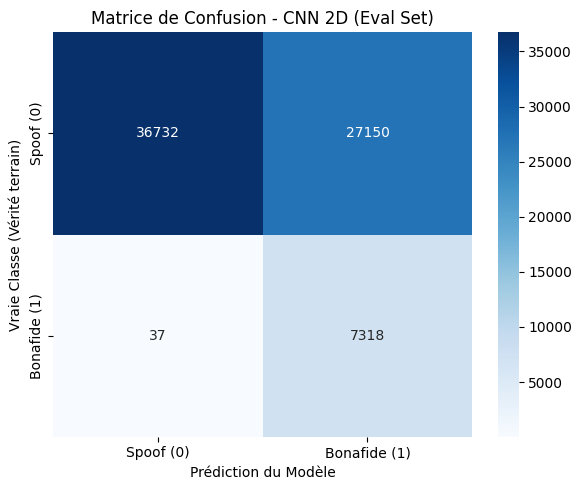

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calcul de la matrice
cm = confusion_matrix(test_labels, test_preds)

# 2. Affichage graphique
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Spoof (0)', 'Bonafide (1)'],
            yticklabels=['Spoof (0)', 'Bonafide (1)'])

plt.xlabel('Prédiction du Modèle')
plt.ylabel('Vraie Classe (Vérité terrain)')
plt.title('Matrice de Confusion - CNN 2D (Eval Set)')
plt.tight_layout()
plt.savefig('matrice_confusion_cnn2d.png')
plt.show()